In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
data = pd.read_csv('Fraud.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [22]:
data.shape

(6362620, 11)

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [24]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

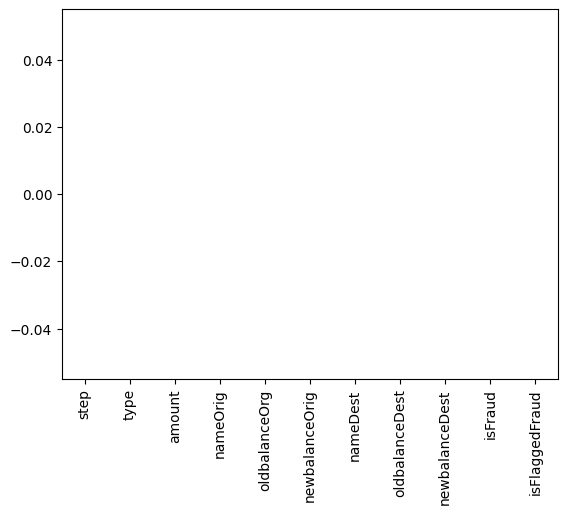

In [25]:
data.isnull().sum().plot.bar()
plt.show()

In [26]:
data.select_dtypes(np.number)

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,9839.64,170136.00,160296.36,0.00,0.00,0,0
1,1,1864.28,21249.00,19384.72,0.00,0.00,0,0
2,1,181.00,181.00,0.00,0.00,0.00,1,0
3,1,181.00,181.00,0.00,21182.00,0.00,1,0
4,1,11668.14,41554.00,29885.86,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,0.00,339682.13,1,0
6362616,743,6311409.28,6311409.28,0.00,0.00,0.00,1,0
6362617,743,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0
6362618,743,850002.52,850002.52,0.00,0.00,0.00,1,0


In [27]:
# Normalization
scaler = StandardScaler()
data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']] = scaler.fit_transform(
    data[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']]
)

# Remove outliers using IQR method
Q1 = data['amount'].quantile(0.25)
Q3 = data['amount'].quantile(0.75)
IQR = Q3 - Q1

# Filtering out the outliers
data = data[~((data['amount'] < (Q1 - 1.5 * IQR)) | (data['amount'] > (Q3 + 1.5 * IQR)))]


In [28]:
# Function to calculate VIF
def calculate_vif(data):
    vif = pd.DataFrame()
    vif['Feature'] = data.columns
    vif['VIF'] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]
    return vif

# Initial VIF calculation, drop columns not used in VIF calculation
X = data.drop(['isFraud', 'isFlaggedFraud', 'nameOrig', 'nameDest'], axis=1)

# Ensure all columns are of numeric type
X = X.astype(float)

vif_data = calculate_vif(X)
print(vif_data)

# Remove features with high VIF (VIF > 10)
while vif_data['VIF'].max() > 10:
    feature_to_remove = vif_data.sort_values('VIF', ascending=False)['Feature'].iloc[0]
    print(f'Removing {feature_to_remove} with VIF {vif_data["VIF"].max()}')
    X = X.drop(columns=[feature_to_remove])
    vif_data = calculate_vif(X)

# Final VIF calculation
print(vif_data)

# Ensure there are no remaining object or categorical types
print(X.dtypes)

ValueError: could not convert string to float: 'PAYMENT'

In [ ]:
# Count the number of fraudulent and non-fraudulent transactions
fraud_counts = data['isFraud'].value_counts()
print(fraud_counts)

# Check if the dataset is balanced
total_transactions = len(data)
fraudulent_transactions = fraud_counts[1]
non_fraudulent_transactions = fraud_counts[0]

print(f"Total transactions: {total_transactions}")
print(f"Fraudulent transactions: {fraudulent_transactions}")
print(f"Non-fraudulent transactions: {non_fraudulent_transactions}")

# Calculate the percentage of fraudulent transactions
fraud_percentage = (fraudulent_transactions / total_transactions) * 100
print(f"Percentage of fraudulent transactions: {fraud_percentage:.2f}%")

# Check if the dataset is balanced
if fraudulent_transactions / total_transactions < 0.4:
    print("The dataset is imbalanced.")
else:
    print("The dataset is balanced.")


isFraud
0    6020183
1       4359
Name: count, dtype: int64
Total transactions: 6024542
Fraudulent transactions: 4359
Non-fraudulent transactions: 6020183
Percentage of fraudulent transactions: 0.07%
The dataset is imbalanced.


In [ ]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
import numpy as np
import pandas as pd

# Sample data (replace this with your dataset)
# X_train: Features, y_train: Target labels
X_train = np.array([[1, 2], [3, 4], [5, 6], [7, 8], [9, 10]])
y_train = np.array([0, 0, 0, 1, 1])

# Before balancing
print("Before balancing:")
print(pd.Series(y_train).value_counts())

# Balancing using RandomOverSampler
oversampler = RandomOverSampler(random_state=42)
X_resampled, y_resampled = oversampler.fit_resample(X_train, y_train)

# After balancing
print("\nAfter balancing (oversampling):")
print(pd.Series(y_resampled).value_counts())

# Balancing using RandomUnderSampler
undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X_train, y_train)

# After balancing
print("\nAfter balancing (undersampling):")
print(pd.Series(y_resampled).value_counts())


Before balancing:
0    3
1    2
Name: count, dtype: int64

After balancing (oversampling):
0    3
1    3
Name: count, dtype: int64

After balancing (undersampling):
0    2
1    2
Name: count, dtype: int64


In [ ]:
y = data['isFraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000)

[[1283096  522959]
 [    441     867]]
              precision    recall  f1-score   support

           0       1.00      0.71      0.83   1806055
           1       0.00      0.66      0.00      1308

    accuracy                           0.71   1807363
   macro avg       0.50      0.69      0.42   1807363
weighted avg       1.00      0.71      0.83   1807363

Accuracy: 0.7104068192167262
ROC-AUC Score: 0.745732978488934


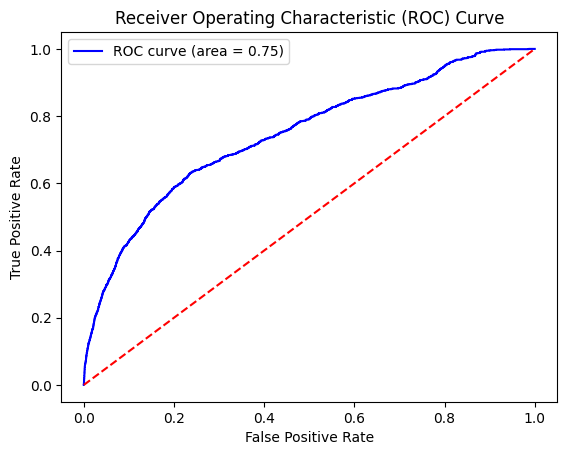

In [ ]:
# Predicting the test set results
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Classification Report
print(classification_report(y_test, y_pred))

# Accuracy Score
print("Accuracy:", accuracy_score(y_test, y_pred))

# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)

# Plotting the ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()
